In [32]:
import pandas as pd

tp = "gawk"
num = 800
# file = f'{tp}_{num}_250302'
file = f'{tp}_{num}_250325'


### 행-열 전치

In [33]:

# df = pd.read_csv('./tuned_parameters.csv')
# df = pd.read_csv('./gcal_2200_250224.csv')
df = pd.read_csv(f'./{file}.csv')
df_transposed = df.T
df_transposed.columns = df_transposed.iloc[0]
df_transposed.drop(df_transposed.index[0], inplace=True)
# df_transposed.drop("Unnamed: 0", axis=1, inplace=True)


df_transposed


df_transposed.to_csv(f'./{file}_temp.csv')
df_transposed = pd.read_csv(f'./{file}_temp.csv')
df_transposed = df_transposed.drop(["Unnamed: 0", "Accumulated Coverage"], axis=1)
df_transposed


,disable-inlining,max-memory-inhibit,klee-call-optimisation,equality-substitution,use-cex-cache,use-forked-solver,watchdog,use-iterative-deepening-time-search,readable-posix-inputs,return-null-on-zero-malloc,...,max-static-cpsolve-pct,array-value-ratio,search,switch-type,smtlib-display-constants,seed-file,sym-arg,sym-files,sym-stdin,Coverage
0,False,True,False,True,True,True,False,False,False,False,...,1.000000,1.000000,random-path,internal,dec,1,15,1 8,8,2972
1,False,True,False,True,True,False,True,True,True,True,...,0.959199,0.688225,nurs:rp,simple,bin,10,11,1 8,6,3563
2,False,False,False,True,True,False,False,False,False,False,...,0.734535,0.688718,dfs,simple,dec,9,21,1 8,11,2853
3,False,True,False,True,True,False,True,True,False,True,...,0.482100,0.051500,bfs,internal,bin,3,6,1 8,6,3500
4,False,True,False,False,False,False,True,True,True,True,...,0.275363,0.044948,nurs:rp,internal,hex,4,15,1 8,8,3362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,False,False,False,False,False,False,False,False,False,False,...,0.679838,0.706676,bfs,simple,hex,3,46,1 8,8,3474
796,False,True,False,False,True,True,True,False,True,False,...,0.679838,0.708756,bfs,simple,hex,2,19,1 8,7,3439
797,False,False,False,True,False,True,True,True,False,True,...,0.679838,0.650752,nurs:rp,simple,hex,2,19,1 8,8,3163
798,False,False,False,False,True,True,False,False,False,False,...,0.679838,0.454095,nurs:rp,simple,hex,3,19,1 8,8,3204


In [34]:
# 문자열 데이터만 선택
string_columns = df_transposed.select_dtypes(include=['object'])

string_columns.columns

Index(['search', 'switch-type', 'smtlib-display-constants', 'sym-files'], dtype='object')

In [35]:
# time = ['seed-time', 'uncovered-update-interval', 'max-solver-time', 'batch-time']
time = ['seed-time', 'uncovered-update-interval']
for t in time:
    df_transposed[t] = df_transposed[t].apply(lambda x: str(x).replace('s', ''))
    df_transposed[t] = pd.to_numeric(df_transposed[t], errors='coerce').astype(int)

In [37]:
# 'sym-files' 열을 공백을 기준으로 분리하고 결과를 새로운 열에 할당
df_transposed[['sym-files-1', 'sym-files-2']] = df_transposed['sym-files'].str.split(expand=True)
df_transposed['sym-files-1'] = pd.to_numeric(df_transposed['sym-files-1'], errors='coerce').astype(int)
df_transposed['sym-files-2'] = pd.to_numeric(df_transposed['sym-files-2'], errors='coerce').astype(int)

df2 = df_transposed.drop(["sym-files", "Coverage"], axis=1)
df2["Coverage"] = df_transposed["Coverage"]

In [38]:
# 문자열 데이터만 선택
string_columns = df2.select_dtypes(include=['object'])

string_columns.columns

Index(['search', 'switch-type', 'smtlib-display-constants'], dtype='object')

In [39]:
df2.to_csv(f'./{file}_dataset.csv', index=False)

In [40]:
import json
df = pd.read_csv(f'./{file}_dataset.csv')
data_list = []
for index, row in df.iterrows():
    config = {}
    for key, value in row.items():
        if key != "Coverage":
            config[key] = value
    data = {
        "id": index,
        "config": config,
        "metric": row["Coverage"]

    }
    data_list.append(data)
    

data_list
json.dump(data_list, open(f'./{file}_ParaSuit.json', 'w'), indent=4)


In [41]:
import json
import pandas as pd
import numpy as np

hyperparameters = []
for key in df.columns:
    
    if key != "Coverage":
        dtype = df[key].dtype
        
        words = key.split('-')
        summary = ''.join(word[0] for word in words)

        if dtype == "int64":
            dtype_str = "numerical"
            valuetype = "int"
            # Convert numpy.int64 to native Python int
            value = [int(df[key].min()), int(df[key].max())]
        elif dtype == "float64":
            dtype_str = "numerical"
            valuetype = "float"
            # Convert numpy.float64 to native Python float
            value = [float(df[key].min()), float(df[key].max())]
        elif dtype == "object":
            dtype_str = "categorical"
            valuetype = "string"
            value = df[key].unique().tolist()
        elif dtype == "bool":
            dtype_str = "boolean"
            valuetype = "boolean"
            value = df[key].unique().tolist()
            
        hyperparameter = {
            "name": key,
            "displayName": summary.upper(),
            "value": value,
            "type": dtype_str,
            "valueType": valuetype
        }
        hyperparameters.append(hyperparameter)

config_json = {
    "name": "ParaSuit",
    "hyperparameters": hyperparameters,
    "metric": {
        "name": "Coverage",
        "displayName": "CVRG"
    }
}

# JSON 파일로 저장
with open('./config.json', 'w') as f:
    json.dump(config_json, f, indent=4)

In [42]:
import pandas as pd


df = pd.read_csv('./src/data/parameter_descriptions.csv')

df['Parameters ']


0                        disable-inlining
1                      max-memory-inhibit
2                  klee-call-optimisation
3                  use-construct-hash-stp
4                        use-visitor-hash
5                   equality-substitution
6                         check-overshift
7                          check-div-zero
8                        use-branch-cache
9                  use-independent-solver
10                         use-call-paths
11                          use-cex-cache
12                      use-forked-solver
13                               watchdog
14                        const-array-opt
15                    zero-seed-extension
16                  warnings-only-to-file
17                  smtlib-human-readable
18              warn-all-external-symbols
19    use-iterative-deepening-time-search
20                          cex-cache-exp
21                  all-external-warnings
22                  readable-posix-inputs
23             return-null-on-zero

In [14]:
import json
# data = json.load(open("./src/data/config.json"))
data = json.load(open("./config.json"))

def get_default_value(value, type):

    

    if (type == "int" or type == "float") and value == "-":
        return None
    if type == "int":
        value = value.replace("s", "")
        return int(value)
    elif type == "float":
        return float(value)
    elif type == "boolean":
        print(value)
        if value == "TRUE":
            print("True")
            return True
        elif value == "FALSE":
            print("False")
            return False
    else:
        return value

for hp in data["hyperparameters"]:
    # 조건에 맞는 행이 있는지 먼저 확인
    matching_rows = df[df["Parameters "] == hp["name"]]
    
    if not matching_rows.empty:  # 매칭되는 행이 있는 경우에만 값을 할당
        hp["description"] = matching_rows["Description"].values[0]
        hp["default"] = matching_rows["Default Value"].values[0]
        hp["defaultValue"] = get_default_value(hp["default"], hp["valueType"])
    elif hp["name"] == "sym-files-1":
        hp["description"] = matching_rows = df[df["Parameters "] == "sym-files"]["Description"].values[0].split(", ")[0]
        hp["default"] = "-"
        hp["defaultValue"] = get_default_value(hp["default"], hp["valueType"])
    elif hp["name"] == "sym-files-2":
        hp["description"] = matching_rows = df[df["Parameters "] == "sym-files"]["Description"].values[0].split(", ")[1]
        hp["default"] = "-"
        hp["defaultValue"] = get_default_value(hp["default"], hp["valueType"])
    else:
        hp["description"] = "No description available"
        hp["default"] = None
        print(f"Warning: No matching parameter found for {hp['name']}")

FALSE
False
TRUE
True
TRUE
True
TRUE
True
TRUE
True
TRUE
True
FALSE
False
FALSE
False
FALSE
False
FALSE
False
FALSE
False
FALSE
False
FALSE
False
FALSE
False
FALSE
False


In [15]:
json.dump(data, open('./config.json', 'w'), indent=4)

In [ ]:
data

### 학습


In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import xgboost as xgb

# 데이터 로드
data = pd.read_csv(f'{file}_dataset.csv')

# 특성(X)과 타겟(y) 분리
X = data.drop(['Coverage'], axis=1)
y = data['Coverage']

# y값에 MinMaxScaler 적용
y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# 레이블 인코딩 적용
le = LabelEncoder()
categorical_columns = list(X.select_dtypes(include=['object']).columns)
for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

# 수치형 변수 스케일링
scaler = StandardScaler()
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_columns:
    X[col] = scaler.fit_transform(X[col].values.reshape(-1, 1))

# 데이터를 train/val/test 세트로 분할 (비율: 7:2:1)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y_scaled, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# XGBoost 모델 학습
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.01,
    random_state=20
)
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 모델 평가 (스케일링된 값)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean squared error (scaled): {mse}")
print(f"R-squared score (scaled): {r2}")

# 원래 스케일로 변환하여 평가
y_test_original = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_original = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()

mse_original = mean_squared_error(y_test_original, y_pred_original)
r2_original = r2_score(y_test_original, y_pred_original)

print(f"\nMean squared error (original scale): {mse_original}")
print(f"R-squared score (original scale): {r2_original}")

# 특성 중요도 출력
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print("\nTop 10 important features:")
print(feature_importance.head(10))


Train set shape: (576, 35) (576,)
Validation set shape: (144, 35) (144,)
Test set shape: (80, 35) (80,)
Mean squared error (scaled): 0.01869135622059313
R-squared score (scaled): 0.5916464718568639

Mean squared error (original scale): 38597.06962852627
R-squared score (original scale): 0.5916464880965566

Top 10 important features:
                  feature  importance
27                 search    0.330914
5       use-forked-solver    0.085896
15             max-memory    0.071891
32              sym-stdin    0.038131
30              seed-file    0.036414
17     max-sym-array-size    0.031614
1      max-memory-inhibit    0.030884
21              seed-time    0.029088
4           use-cex-cache    0.027581
3   equality-substitution    0.024525


In [44]:
import shap

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=7,
    learning_rate=0.05,
    n_estimators=1000,
    min_child_weight=3,
    subsample=0.8,
    random_state=20
)
model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)


In [45]:

# 예측
y_pred = model.predict(X_test)


# 모델 평가 (스케일링된 값)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean squared error (scaled): {mse}")
print(f"R-squared score (scaled): {r2}")

# 원래 스케일로 변환하여 평가
y_test_original = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_original = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()

mse_original = mean_squared_error(y_test_original, y_pred_original)
r2_original = r2_score(y_test_original, y_pred_original)

print(f"\nMean squared error (original scale): {mse_original}")
print(f"R-squared score (original scale): {r2_original}")

# 특성 중요도 출력
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print("\nTop 10 important features:")
print(feature_importance.head(10))

Mean squared error (scaled): 0.016586410460413765
R-squared score (scaled): 0.6376336125209618

Mean squared error (original scale): 34250.42592528761
R-squared score (original scale): 0.6376335860367239

Top 10 important features:
                  feature  importance
27                 search    0.285061
5       use-forked-solver    0.102606
15             max-memory    0.070682
1      max-memory-inhibit    0.052951
28            switch-type    0.042550
3   equality-substitution    0.038476
30              seed-file    0.037131
4           use-cex-cache    0.036889
17     max-sym-array-size    0.026289
11    named-seed-matching    0.022242


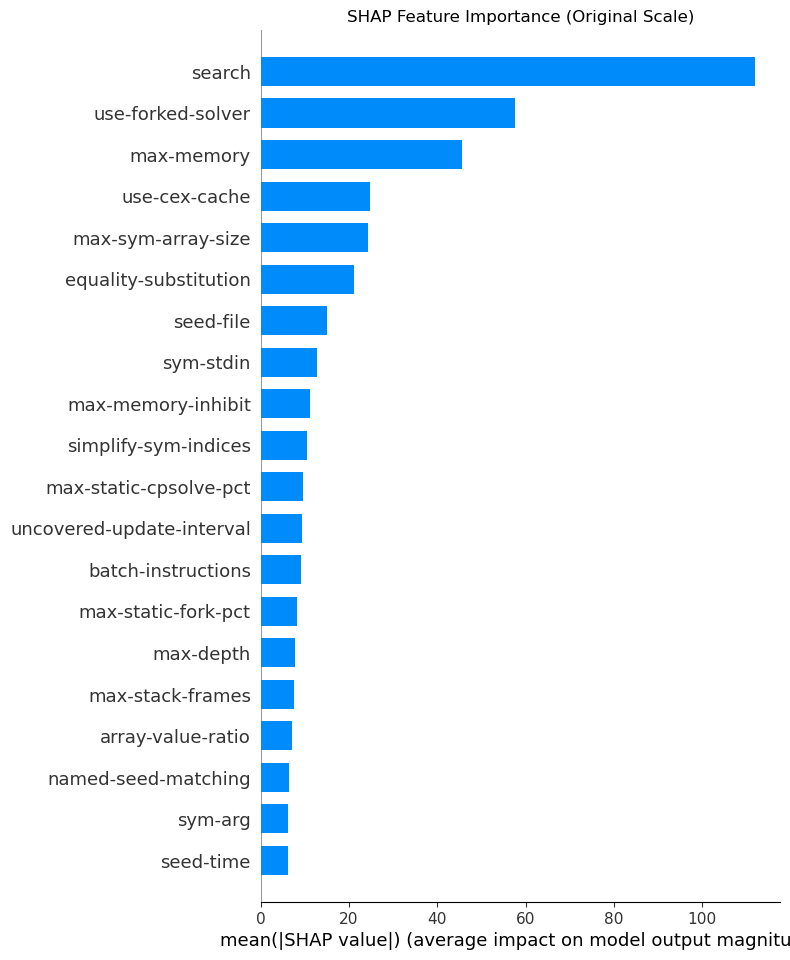


Top 10 features by SHAP importance (original scale):
                  feature  importance
27                 search  112.034332
5       use-forked-solver   57.716488
15             max-memory   45.546333
4           use-cex-cache   24.675938
17     max-sym-array-size   24.388613
3   equality-substitution   21.146275
30              seed-file   15.073644
32              sym-stdin   12.847060
1      max-memory-inhibit   11.265284
10   simplify-sym-indices   10.471395


<Figure size 1000x600 with 0 Axes>

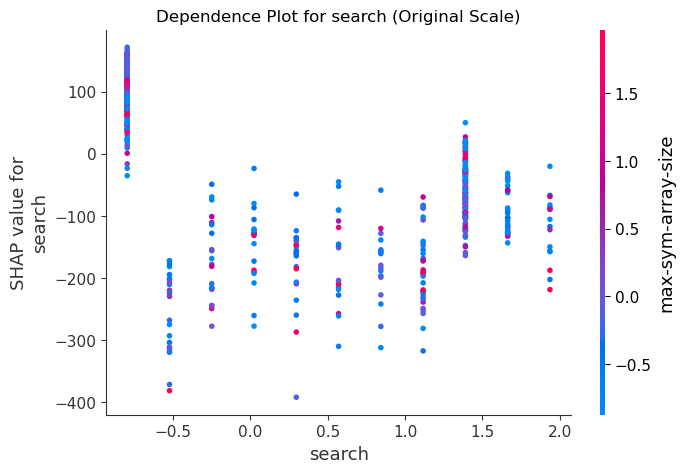


SHAP Value Statistics (Original Scale):

Absolute SHAP value means:
                  Feature  Mean Absolute SHAP  Std Absolute SHAP
27                 search          112.034332          58.083752
5       use-forked-solver           57.716488          24.592730
15             max-memory           45.546333          52.376526
4           use-cex-cache           24.675938          12.980825
17     max-sym-array-size           24.388613          20.888620
3   equality-substitution           21.146275          12.765181
30              seed-file           15.073644          17.909355
32              sym-stdin           12.847060           9.572273
1      max-memory-inhibit           11.265284          15.007706
10   simplify-sym-indices           10.471395           6.377639


<Figure size 2000x300 with 0 Axes>

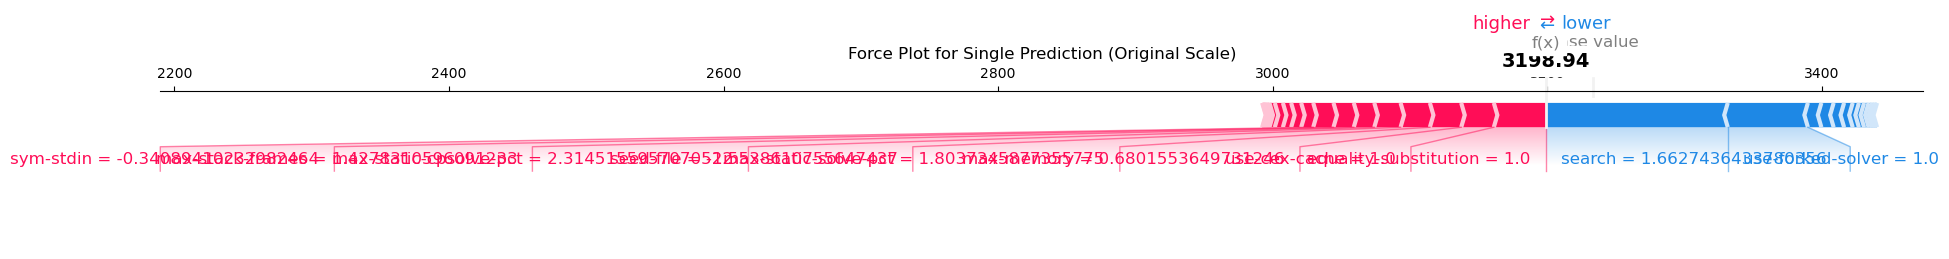

In [46]:
# 원본 스케일로 SHAP 값 변환
import shap
import matplotlib.pyplot as plt

# 1. 최적 모델 가져오기
# model = grid_search.best_estimator_

# 2. SHAP 값 계산
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# 3. SHAP 값을 원래 스케일로 변환
# y_scaler는 이전에 사용한 MinMaxScaler 객체입니다
scaled_expected_value = explainer.expected_value
original_expected_value = y_scaler.inverse_transform([[scaled_expected_value]])[0][0]

# SHAP 값을 원래 스케일로 변환
# MinMaxScaler의 스케일 factor를 사용하여 변환
scale_factor = (y_scaler.data_max_ - y_scaler.data_min_)[0]
original_scale_shap_values = shap_values * scale_factor

# 4. 시각화
plt.figure(figsize=(12, 6))
shap.summary_plot(
    original_scale_shap_values, 
    X,
    show=False,
    plot_type="bar"
)
plt.title("SHAP Feature Importance (Original Scale)")
plt.show()

# 5. 상세 분석을 위한 데이터프레임 생성
shap_df = pd.DataFrame(
    original_scale_shap_values,
    columns=X.columns
)

# 평균 절대 SHAP 값으로 특성 중요도 계산
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(original_scale_shap_values).mean(axis=0)
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\nTop 10 features by SHAP importance (original scale):")
print(feature_importance.head(10))

# 6. 특정 예측에 대한 waterfall 플롯 (원래 스케일)
# plt.figure(figsize=(10, 6))
# shap.plots._waterfall.waterfall_plot(
#     original_expected_value,
#     original_scale_shap_values[0],
#     X.iloc[0],
#     max_display=10
# )
# plt.title("Waterfall Plot for Single Prediction (Original Scale)")
# plt.show()

# 7. 주요 특성의 의존성 플롯
top_feature = feature_importance['feature'].iloc[0]
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature,
    original_scale_shap_values,
    X,
    show=False
)
plt.title(f"Dependence Plot for {top_feature} (Original Scale)")
plt.show()

# 8. 통계 요약
print("\nSHAP Value Statistics (Original Scale):")
print("\nAbsolute SHAP value means:")
print(pd.DataFrame({
    'Feature': X.columns,
    'Mean Absolute SHAP': np.abs(original_scale_shap_values).mean(axis=0),
    'Std Absolute SHAP': np.abs(original_scale_shap_values).std(axis=0)
}).sort_values('Mean Absolute SHAP', ascending=False).head(10))

# 9. 특정 예측에 대한 force plot (원래 스케일)
sample_idx = 0
plt.figure(figsize=(20, 3))
shap.force_plot(
    original_expected_value,
    original_scale_shap_values[sample_idx],
    X.iloc[sample_idx],
    matplotlib=True,
    show=False
)
plt.title("Force Plot for Single Prediction (Original Scale)")
plt.tight_layout()
plt.show()

In [47]:
# df = pd.DataFrame(shap_values, columns=X.columns)
# df
# df.to_json('shap_values.json', orient='records')

df = pd.DataFrame(original_scale_shap_values, columns=X.columns)
df
df.to_json(f'{file}_original_scale_shap_values.json', orient='records')


In [48]:
# 1. 스케일된 기준값 확인
scaled_base_value = explainer.expected_value
print("Scaled base value:", scaled_base_value)

# 2. 원래 스케일로 변환
original_base_value = y_scaler.inverse_transform([[scaled_base_value]])[0][0]
print("Original base value:", original_base_value)

# # 3. 실제 타겟값의 평균과 비교
# actual_mean = y_scaler.inverse_transform(y.reshape(-1, 1)).mean()
# print("Actual mean of target:", actual_mean)

Scaled base value: 0.49721637
Original base value: 3233.4999289810653


### set 데이터셋 정제

In [49]:
import pandas as pd
import numpy as np
# 데이터 읽기
# file = open(f'{tp}_{num}.txt', 'r')
# data = file.read()
print(f'{tp}_{num}.txt')

with open(f'{tp}_{num}.txt', 'r') as file2:
    data = file2.read()
    text_trials = data.split("\n")
    # print("trials", trials[0])
    trials = []
    for trial in text_trials:
        
        trial = trial.strip("{}").split(", ")
        if trial[0] == 'set()':
            trials.append([])
        elif len(trial) == 1 and trial[0] == '':
            trials.append([])
        else:
            trial = [int(t) for t in trial]
            trials.append(trial)

# trials = np.array(trials)
# trials.shape()



gawk_800.txt


In [50]:
# 모든 유니크한 숫자 찾기
all_numbers = sorted(set(num for trial in trials for num in trial))
print(max(all_numbers))
len(all_numbers)


4396


4379

In [51]:
# 모든 유니크한 숫자 찾기
all_numbers = sorted(set(num for trial in trials for num in trial))

# DataFrame 생성
df = pd.DataFrame(index=range(len(trials)), columns=all_numbers)

# DataFrame 채우기
for i, trial in enumerate(trials):
    df.loc[i] = [1 if num in trial else 0 for num in all_numbers]

# 결과 확인
print(df.head())
print(f"\nDataFrame shape: {df.shape}")

  1    2    3    4    5    6    7    8    9    10    ... 4387 4388 4389 4390  \
0    1    1    1    1    1    1    1    1    1    1  ...    0    0    0    0   
1    1    1    1    1    1    1    1    1    1    1  ...    0    0    0    0   
2    1    1    1    1    1    1    1    1    1    1  ...    0    0    0    0   
3    1    1    1    1    1    1    1    1    1    1  ...    0    0    0    0   
4    1    1    1    1    1    1    1    1    1    1  ...    0    0    0    0   

  4391 4392 4393 4394 4395 4396  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 4379 columns]

DataFrame shape: (802, 4379)


In [52]:
df.to_csv(f'{file}_coverage_set.csv', index=False)
df = pd.read_csv(f'{file}_coverage_set.csv')
df.to_json(f'{file}_coverage_set.json', orient='records')


### UMAP 그리기

/opt/anaconda3/envs/swt/lib/python3.11/site-packages/umap/umap_.py:1879: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/opt/anaconda3/envs/swt/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/opt/anaconda3/envs/swt/lib/python3.11/site-packages/umap/umap_.py:126: UserWarning: A few of your vertices were disconnected from the manifold.  This shouldn't cause problems.
Disconnection_distance = 1 has removed 1602 edges.
It has only fully disconnected 1 vertices.
Use umap.utils.disconnected_vertices() to identify them.
  warn(
/opt/anaconda3/envs/swt/lib/python3.11/site-packages/umap/umap_.py:1879: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be 

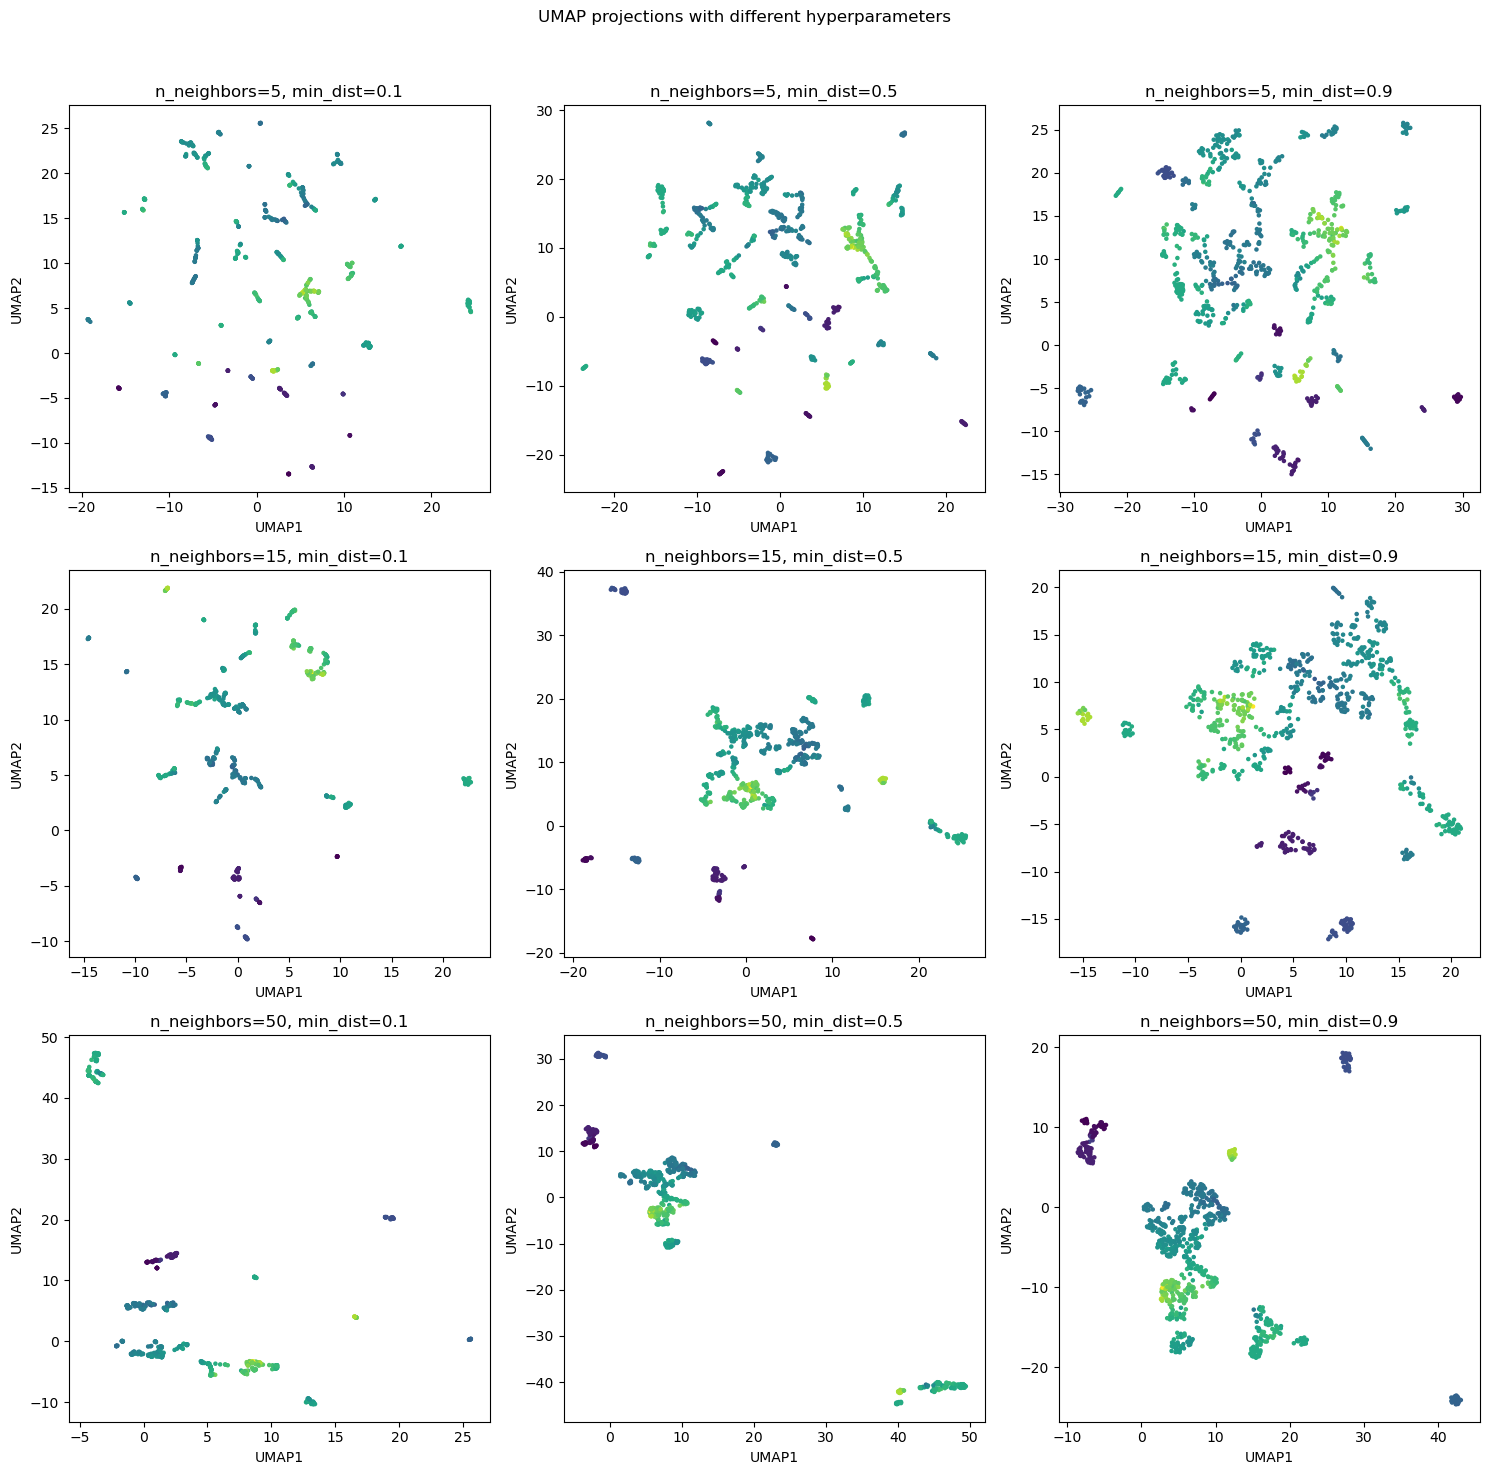

{'n_neighbors': 5, 'min_dist': 0.1, 'x': -10.395661354064941, 'y': -4.732876777648926}


In [53]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import json

def jaccard_distance(a, b):
    intersection = np.logical_and(a, b)
    union = np.logical_or(a, b)
    union_sum = union.sum()
    if union_sum == 0:
        return 0.0  # 두 벡터가 모두 0일 때
    return 1.0 - intersection.sum() / union_sum

# 데이터 준비
df = pd.read_csv(f'{file}_coverage_set.csv')
X = df.values

# 자카드 거리 행렬 생성
distance_matrix = squareform(pdist(X, metric=jaccard_distance))

# 하이퍼파라미터 설정
n_neighbors_list = [5, 15, 50]
min_dist_list = [0.1, 0.5, 0.9]

# 결과를 저장할 리스트
trials = []

# 결과 시각화를 위한 플롯 설정
fig, axes = plt.subplots(len(n_neighbors_list), len(min_dist_list), figsize=(15, 15))
fig.suptitle('UMAP projections with different hyperparameters')

for i, n_neighbors in enumerate(n_neighbors_list):
    for j, min_dist in enumerate(min_dist_list):
        # UMAP을 사용한 차원 축소
        umap_model = umap.UMAP(n_components=2, metric='jaccard', n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
        umap_positions = umap_model.fit_transform(X)
        
        # 각 trial의 UMAP 위치 정보 저장
        for trial_idx in range(len(X)):
            if trial_idx >= len(trials):
                trials.append({"id": trial_idx, "umap_positions": []})
            
            trials[trial_idx]["umap_positions"].append({
                "n_neighbors": n_neighbors,
                "min_dist": min_dist,
                "x": float(umap_positions[trial_idx, 0]),
                "y": float(umap_positions[trial_idx, 1])
            })
        
        # 결과 시각화
        ax = axes[i, j]
        scatter = ax.scatter(umap_positions[:, 0], umap_positions[:, 1],
                             c=np.sum(X, axis=1), cmap='viridis', s=5)
        ax.set_title(f'n_neighbors={n_neighbors}, min_dist={min_dist}')
        ax.set_xlabel('UMAP1')
        ax.set_ylabel('UMAP2')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# JSON 파일로 저장
with open(f'{file}_umap_results.json', 'w') as f:
    json.dump({"trials": trials}, f, indent=2)

# 결과 확인 (첫 번째 trial의 첫 번째 UMAP 위치 출력)
print(trials[0]["umap_positions"][0])

In [54]:
df_umap_positions = pd.DataFrame(umap_positions, columns=['umap_x', 'umap_y'])


df_umap_positions.to_json(f'{file}_umap_positions.json', orient='records')

In [55]:
df_umap_positions

,umap_x,umap_y
0,42.164780,-24.191757
1,6.740511,-9.906734
2,28.017490,19.190672
3,4.739161,-13.173306
4,7.575946,-3.848578
...,...,...
797,2.719687,-2.129156
798,2.946570,-3.085584
799,9.900660,-8.835425
800,7.317029,-11.197721


## 모든 데이터 Json 파일로 합치기

In [58]:

import json
file = f'{tp}_{num}_250325'
# 기존 JSON 파일 불러오기
input_file = f'{file}_ParaSuit.json'  # 기존 JSON 파일 이름
with open(input_file, 'r') as f:
    data = json.load(f)

shape_file = f'{file}_original_scale_shap_values.json'  # 기존 JSON 파일 이름
with open(shape_file, 'r') as f:
    shap_data = json.load(f)

# branch_coverage_file = f'{file}_coverage_set.json'  # 기존 JSON 파일 이름
# with open(branch_coverage_file, 'r') as f:
#     coverage_data = json.load(f)

branch_file = f'{tp}_{num}.txt'
with open(branch_file, 'r') as file2:
    bc_data = file2.read()
    text_trials = bc_data.split("\n")
    # print("trials", trials[0])
    branches = []
    for bc in text_trials:
        
        bc = bc.strip("{}").split(", ")
        if bc[0] == 'set()':
            branches.append([])
        elif len(bc) == 1 and bc[0] == '':
            branches.append([])
        else:
            bc = [int(b) for b in bc]
            branches.append(bc)



umap_positions_file = f'{file}_umap_positions.json'  # 기존 JSON 파일 이름
with open(umap_positions_file, 'r') as f:
    umap_data = json.load(f)


umap_positions_file = f'{file}_umap_results.json'  # 기존 JSON 파일 이름
with open(umap_positions_file, 'r') as f:
    umap_data = json.load(f)



for i, trial in enumerate(data):
    trial["shap_values"] = shap_data[i]
    # print(coverage_data[i].values())
    # break
    trial["branch"] = branches[i]
    trial["umap_x"] = float(umap_positions[i][0])
    trial["umap_y"] = float(umap_positions[i][1])
    trial["umap_positions"] = umap_data['trials'][i]['umap_positions']

# JSON 파일로 저장
output_file = f'tuned_parameters_{file}_final.json'  # 새로 저장할 JSON 파일 이름
with open(output_file, 'w') as f:
    json.dump(data, f, indent=4)

In [ ]:
import json
# 기존 JSON 파일 불러오기
input_file = 'ParaSuit.json'  # 기존 JSON 파일 이름
with open(input_file, 'r') as f:
    data = json.load(f)


umap_positions_file = 'umap_positions.json'  # 기존 JSON 파일 이름
with open(umap_positions_file, 'r') as f:
    umap_data = json.load(f)


for i, trial in enumerate(data):
    trial["umap_x"] = float(umap_positions[i][0])
    trial["umap_y"] = float(umap_positions[i][1])

# JSON 파일로 저장
output_file = 'ParaSuit_all.json'  # 새로 저장할 JSON 파일 이름
with open(output_file, 'w') as f:
    json.dump(data, f, indent=4)

In [ ]:
import json
# 기존 JSON 파일 불러오기
input_file = 'ParaSuit.json'  # 기존 JSON 파일 이름
with open(input_file, 'r') as f:
    data = json.load(f)


umap_positions_file = 'umap_results.json'  # 기존 JSON 파일 이름
with open(umap_positions_file, 'r') as f:
    umap_data = json.load(f)
umap_data['trials']


for i, trial in enumerate(data):
    # trial["umap_x"] = float(umap_positions[i][0])
    # trial["umap_y"] = float(umap_positions[i][1])
    trial["umap_positions"] = umap_data['trials'][i]['umap_positions']

# # JSON 파일로 저장
output_file = 'ParaSuit_all.json'  # 새로 저장할 JSON 파일 이름
with open(output_file, 'w') as f:
    json.dump(data, f, indent=4)

In [ ]:
import json

input_file = "./src/data/ParaSuit_encoded.json"
shap_file = "./original_scale_shap_values.json"
with open(input_file, 'r') as f:
    data = json.load(f)

with open(shap_file, 'r') as f:
    shap_data = json.load(f)

for i, trial in enumerate(data):
    print(trial)
    del trial['shap_values']
    trial['shap_values'] = shap_data[i]

In [ ]:
json.dump(data, open('./ParaSuit.json', 'w'), indent=4)